## Part 1 of the Thesis
We use the Penmanshiel dataset to create a controlled environment.


In this part we determine the threshold used to declare reconstruction errors as anomalies. This defined threshold will be used for part 2.

In this part of this thesis we also explore the anomaly detection capabilities of the autoencoder on selected anomalies.

If further content exist for this part, you can check project_root/src/further_content/





In [1]:
from helperfunctions import helper as hfn
from helperfunctions import intern_constants as ic
from helperfunctions.pretty_print import PrettyPrint as pp
from helperfunctions import training_lib as tl
# from helperfunctions.controlled_env import Inject_Anomalies as ia
# from helperfunctions.controlled_env import Anom_Type as anomtype
# from helperfunctions.controlled_env import Eval_Anom as ea
from torch import nn
from helperfunctions import controlled_env as ce
from helperfunctions.helper import load_feature_order
from typing import cast, Tuple
import pandas as pd
from glob import glob
import os
import numpy as np

In [2]:
os.makedirs(ic.PATH_PART1_VAL_SET_INJ_DIR , exist_ok=True)
os.makedirs(ic.PATH_PART1_VAL_LOSS_DIR, exist_ok=True)
os.makedirs(ic.PATH_PART1_TEST_LOSS_DIR, exist_ok=True)
os.makedirs(ic.PATH_PART1_K_AGG_METRICS_DIR, exist_ok=True)

out_dir = ic.PATH_PART1_K_AGG_METRICS_DIR

fp_per_wt_k = out_dir / "per_wt_k_metrics.csv"
fp_per_event =  out_dir / "per_event_metrics.csv"
fp_best_k = out_dir / "best_ks_per_wt.csv"
fp_anom_view =  out_dir / "anom_overview.csv"
fp_thresh =  out_dir / "thresholds_part2.csv"
fp_t_grid =  out_dir / "threshold_grid.csv"
fp_sigma = out_dir / "sigma_val_mean.csv"
fp_cand = out_dir / "candidates_k_per_wt.csv"

### Data set creation

In [3]:
cfg_dummy = hfn.TrainConfig(config_name="p1_dummy_cfg", part1=True)

{
  "config_name": "p1_dummy_cfg",
  "batch_size": 252,
  "epochs": 30,
  "lr": 0.001,
  "weight_decay": 0.0,
  "grad_clip_norm": 1.0,
  "patience": 5,
  "min_delta": 1e-06,
  "depth": null,
  "input_dim": 38,
  "base_width": 38,
  "width_decay": 0.5,
  "bottleneck_min": 2,
  "activation": "relu",
  "dropout": 0.0,
  "leaky_relu_slope": null,
  "seed": 32,
  "base_seed": 32,
  "T0": 10,
  "Tmult": 2,
  "eta_min_lower_bound": 1e-06,
  "val_split": 0.4,
  "layer_depths": [
    2,
    3,
    4,
    5
  ],
  "available_start": "2019-04-05 14:00:00",
  "available_end": "2022-12-31 23:50:00",
  "min_gap": 4320,
  "val_start_time": "2019-11-06 18:40:00",
  "val_end_time": "2020-04-01 04:00:00",
  "test_start_time": "2019-11-06 18:40:00",
  "test_end_time": "2020-04-01 04:00:00",
  "signal_cols": [
    "Ambient temperature (converter) (°C)",
    "Drive train acceleration (mm/ss)",
    "Gear oil inlet pressure (bar)",
    "Gear oil pump pressure (bar)",
    "Gearbox speed (RPM)",
    "Generator

In [4]:
print(cfg_dummy.val_start_time)
print(cfg_dummy.val_end_time)

2019-11-06 18:40:00
2020-04-01 04:00:00


Anomaly injection time period

In [5]:
print(ic.START_ANOM)
print(ic.END_ANOM)

2019-12-15 00:00:00
2020-04-01 00:00:00


In [6]:
fo = hfn.load_feature_order()
print(*fo, sep="\n")

Ambient temperature (converter) (°C)
Drive train acceleration (mm/ss)
Gear oil inlet pressure (bar)
Gear oil pump pressure (bar)
Gearbox speed (RPM)
Generator bearing front temperature (°C)
Generator bearing rear temperature (°C)
Generator RPM (RPM)
Hub temperature (°C)
Motor current axis 1 (A)
Motor current axis 2 (A)
Motor current axis 3 (A)
Nacelle ambient temperature (°C)
Nacelle position (°)
Nacelle temperature (°C)
Power (kW)
Rotor bearing temp (°C)
Rotor speed (RPM)
Stator temperature 1 (°C)
Temp. top box (°C)
Temperature motor axis 1 (°C)
Temperature motor axis 2 (°C)
Temperature motor axis 3 (°C)
Vane position 1+2 (°)
Wind direction (°)
Wind speed (m/s)
Blade angle (pitch position) A (°)
Blade angle (pitch position) B (°)
Blade angle (pitch position) C (°)
Front bearing temperature (°C)
Gear oil inlet temperature (°C)
Gear oil temperature (°C)
Rear bearing temperature (°C)
Tower Acceleration X (mm/ss)
Tower Acceleration Y (mm/ss)
Transformer cell temperature (°C)
Transformer t

In [7]:
wt = 1

SIG_ADD =  "Rotor bearing temp (°C)"
SIG_POINT= "Stator temperature 1 (°C)"
SIG_MULT = "Transformer cell temperature (°C)"
SIG_CORR1= "Generator bearing front temperature (°C)"
SIG_CORR2= "Generator bearing rear temperature (°C)"

intensities_add = [15, 25.0]
intensities_mult = [1.2]
intensities_corr = [-0.9, 0.0, 0.8]
intensities_point = [50, 100]

specs: list[ce.AnomalySpec] = [
    ce.AnomalySpec(
        wt_id= wt,
        category=ce.AnomCategory.ADD,
        primary_signal=SIG_ADD,
        intensities=intensities_add,
    ),
    ce.AnomalySpec(
        wt_id= wt,
        category=ce.AnomCategory.MULT,
        primary_signal=SIG_MULT,
        intensities=intensities_mult,
    ),
    ce.AnomalySpec(
        wt_id= wt,
        category=ce.AnomCategory.CORR,
        primary_signal=SIG_CORR1,
        secondary_signal=SIG_CORR2,
        intensities=intensities_corr,
    ),
    ce.AnomalySpec(
        wt_id= wt,
        category=ce.AnomCategory.POINT,
        primary_signal=SIG_POINT,
        intensities=intensities_point,
    ),
]

print(specs)

[AnomalySpec(wt_id=1, category=<AnomCategory.ADD: 1>, primary_signal='Rotor bearing temp (°C)', secondary_signal=None, intensities=[15, 25.0], k_anoms=1), AnomalySpec(wt_id=1, category=<AnomCategory.MULT: 3>, primary_signal='Transformer cell temperature (°C)', secondary_signal=None, intensities=[1.2], k_anoms=1), AnomalySpec(wt_id=1, category=<AnomCategory.CORR: 4>, primary_signal='Generator bearing front temperature (°C)', secondary_signal='Generator bearing rear temperature (°C)', intensities=[-0.9, 0.0, 0.8], k_anoms=1), AnomalySpec(wt_id=1, category=<AnomCategory.POINT: 2>, primary_signal='Stator temperature 1 (°C)', secondary_signal=None, intensities=[50, 100], k_anoms=1)]


In [8]:
n_windows_by_cat = ce.Part1.infer_windows_by_category_from_specs(specs)

print(n_windows_by_cat)

{<AnomCategory.ADD: 1>: 2, <AnomCategory.MULT: 3>: 1, <AnomCategory.CORR: 4>: 3, <AnomCategory.POINT: 2>: 2}


In [9]:
anomaly_plan, cat_windows  = cast(Tuple[ce.AnomalyPlan, pd.DataFrame] ,ce.Part1.build_plan( 
    start=ic.START_ANOM,
    end=ic.END_ANOM,
    gap_in_hours=48,
    min_len_hours=168,
    k_add=n_windows_by_cat[ce.AnomCategory.ADD],
    k_point=n_windows_by_cat[ce.AnomCategory.POINT],
    k_mult=n_windows_by_cat[ce.AnomCategory.MULT],
    k_corr=n_windows_by_cat[ce.AnomCategory.CORR],
    return_cat_windows=True))

cat_win_path = out_dir / "anom_windows.csv"
cat_windows.to_csv(cat_win_path, index=False, date_format="%Y-%m-%d %H:%M:%S")

display(anomaly_plan)
display(cat_windows)

AnomalyPlan(ts0=Timestamp('2019-12-15 00:00:00'), ts1=Timestamp('2020-04-01 00:00:00'), gap=Timedelta('2 days 00:00:00'), min_len=Timedelta('7 days 00:00:00'), windows_by_cat={<AnomCategory.ADD: 1>: [(Timestamp('2019-12-15 00:00:00'), Timestamp('2019-12-22 00:00:00')), (Timestamp('2019-12-24 00:00:00'), Timestamp('2019-12-31 00:00:00'))], <AnomCategory.POINT: 2>: [(Timestamp('2020-01-09 00:00:00'), Timestamp('2020-01-09 00:00:00')), (Timestamp('2020-01-18 00:00:00'), Timestamp('2020-01-18 00:00:00'))], <AnomCategory.MULT: 3>: [(Timestamp('2020-01-20 00:00:00'), Timestamp('2020-01-27 00:00:00'))], <AnomCategory.CORR: 4>: [(Timestamp('2020-01-29 00:00:00'), Timestamp('2020-02-05 00:00:00')), (Timestamp('2020-02-07 00:00:00'), Timestamp('2020-02-14 00:00:00')), (Timestamp('2020-02-16 00:00:00'), Timestamp('2020-02-23 00:00:00'))]})

,category,window_idx,ts_start,ts_end
0,ADD,0,2019-12-15,2019-12-22
1,ADD,1,2019-12-24,2019-12-31
2,CORR,0,2020-01-29,2020-02-05
3,CORR,1,2020-02-07,2020-02-14
4,CORR,2,2020-02-16,2020-02-23
5,MULT,0,2020-01-20,2020-01-27
6,POINT,0,2020-01-09,2020-01-09
7,POINT,1,2020-01-18,2020-01-18


In [10]:
dfs = []
# 
files = glob(os.path.join(ic.PATH_IMPUTED, "*.csv"))
for filepath in files:
    df = pd.read_csv(filepath, parse_dates=[ic.TS_COL])
    dfs.append(df)
    
df_val2_part1_raw = pd.concat(dfs, ignore_index=True)
df_val2_part1_raw[ic.TS_COL] = pd.to_datetime(df_val2_part1_raw[ic.TS_COL], errors="raise")

In [11]:
df_val_injected, df_gt = ce.Part1.apply_plan_and_build(df_raw_sigs=df_val2_part1_raw,
                                                        specs=specs,
                                                        plan= anomaly_plan)

gt_union_df = ce.Part1._gt_union_per_wt(df_gt)

display(gt_union_df.head())

df_gt.to_csv(out_dir / "gt_events_part1", index=False)

,gt_id,wt_id,category,signals,window_idx,ts_start,ts_end,anom_type,intensity
0,0,1,WT_MEAN,Mean,0,2019-12-15,2019-12-22,UNION,NaN
1,1,1,WT_MEAN,Mean,1,2019-12-24,2019-12-31,UNION,NaN
2,2,1,WT_MEAN,Mean,2,2020-01-09,2020-01-09,UNION,NaN
3,3,1,WT_MEAN,Mean,3,2020-01-18,2020-01-18,UNION,NaN
4,4,1,WT_MEAN,Mean,4,2020-01-20,2020-01-27,UNION,NaN


In [12]:
for wt_id in sorted(df_val_injected[ic.WT_ID].unique()):
    df_wt_test = df_val_injected[df_val_injected[ic.WT_ID] == wt_id].copy()
    fp = ic.PATH_PART1_VAL_SET_INJ_DIR / f"wt_{int(wt_id)}_part1_val_set_injected.csv"
    df_wt_test.to_csv(fp, index=False)

In [13]:
_, val_loader, val_inj_loader = hfn.build_dataloaders(
    train_csv_dir=ic.PATH_PC_FILTERING,
    val_csv_dir=ic.PATH_IMPUTED,
    test_csv_dir=ic.PATH_PART1_VAL_SET_INJ_DIR,
    cfg=cfg_dummy
)

In [14]:
best = tl.get_model_results(ic.PATH_TO_BEST_MODEL_DIR, best_n=1)
ae, optim, ckpt, sched, scaler = best[0]

ae = ae.to(cfg_dummy.device).eval()

C:\Users\admin\AppData\Roaming\Python\Python312\site-packages\torch\amp\grad_scaler.py:132: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(


name:activation__Seed_32_uid_8c8d353bea.pth
 best val error:0.17704901592204464
 best train error:0.009280807258664099
 model params:5425



In [15]:
loss_fn = nn.MSELoss(reduction="none")

In [16]:
val_df_eval = tl.eval_model(
    model=ae,
    data_loader=val_loader,
    device=cfg_dummy.device,
    loss_fn = loss_fn
)

val_df_eval.to_csv(ic.PATH_PART1_VAL_LOSS_DIR/ "df_val_eval.csv", index=False)

prep_val_df_eval = ce.Part1.prepare_df_eval_threshold_computing(df_eval=val_df_eval,
                                                                include_mean=True,
                                                                include_signal_wise_re=False,
                                                                )

display(prep_val_df_eval.head())





,Date and time,WT_ID,Signal,Reconstruction Error
0,2019-11-06 18:40:00,1,Mean,0.189898
1,2019-11-06 18:50:00,1,Mean,0.188576
2,2019-11-06 19:00:00,1,Mean,0.187850
3,2019-11-06 19:10:00,1,Mean,0.191107
4,2019-11-06 19:20:00,1,Mean,0.185498


In [17]:
sigma_df = ce.Part1.compute_val_sigma(re_val_df=prep_val_df_eval)
sigma_df.to_csv(fp_sigma, index=False)

In [18]:
try:
    val_inj_df_eval = pd.read_csv(ic.PATH_PART1_TEST_LOSS_DIR/ "df_inj_eval.csv")
except FileNotFoundError:
    
    val_inj_df_eval  =tl.eval_model(
        model=ae,
        data_loader=val_inj_loader,
        device=cfg_dummy.device,
        loss_fn= loss_fn
    )

    val_inj_df_eval.to_csv(ic.PATH_PART1_TEST_LOSS_DIR/ "df_inj_eval.csv", index=False)

prep_val_inj_df_eval = ce.Part1.prepare_df_eval_threshold_computing(df_eval=val_inj_df_eval,
                                                                 include_mean=True,
                                                                 include_signal_wise_re=False)


In [19]:

# k_values = ce.Part1._k_grid(max=10, min=1, step=1)
# k_values2 = ce.Part1._k_grid(max=1,min=0.1, step=0.1)



# k_values = (k_values + 
#             k_values2 + 
#             )

k_values = ce.Part1._k_grid(max=1, min=0.9, step=0.1)
k2_values = ce.Part1._k_grid(max=3.1, min=2.9, step=0.1)

k_values = k_values + k2_values

In [20]:
thresholds_grid_df = ce.Part1.build_threshold_grid(
    sigma_df=sigma_df,
    k_values= k_values,
)

display(thresholds_grid_df.head())

thresholds_grid_df.to_csv(fp_t_grid, index=False)

,WT_ID,Signal,mu,sigma,k,threshold
0,1,Mean,0.013096,0.029094,0.9,0.039281
1,1,Mean,0.013096,0.029094,1.0,0.042190
2,1,Mean,0.013096,0.029094,2.9,0.097469
3,1,Mean,0.013096,0.029094,3.0,0.100379
4,1,Mean,0.013096,0.029094,3.1,0.103288


In [21]:
per_wt_k_df, per_event_df = ce.Part1.eval_events_over_k(
    wt_sig_loss_df=prep_val_inj_df_eval,
    gt_union_df=gt_union_df,
    gt_events_df=df_gt,
    thresholds_grid_df=thresholds_grid_df,
    fp_merge_gap_steps=0,
)

per_wt_k_df.to_csv(fp_per_wt_k, index=False)
per_event_df.to_csv(fp_per_event, index=False)

In [22]:
display(per_wt_k_df.head(20))
display(per_event_df.head(10))

,WT_ID,k,mu,sigma,threshold,tp,fn,fp,precision,recall,f1,FAR_per_day,latency_mean
0,1,0.9,0.013096,0.029094,0.039281,7,1,249,0.027344,0.875,0.053030,1.682432,109.142857
1,1,1.0,0.013096,0.029094,0.042190,7,1,236,0.028807,0.875,0.055777,1.594595,111.714286
2,1,2.9,0.013096,0.029094,0.097469,4,4,177,0.022099,0.500,0.042328,1.195946,408.250000
3,1,3.0,0.013096,0.029094,0.100379,4,4,176,0.022222,0.500,0.042553,1.189189,408.250000
4,1,3.1,0.013096,0.029094,0.103288,4,4,174,0.022472,0.500,0.043011,1.175676,408.250000


,WT_ID,k,mu,sigma,threshold,anom_type,signals,ts_start,ts_end,latency,intensity
0,1,0.9,0.013096,0.029094,0.039281,ADD,Rotor bearing temp (°C),2019-12-15,2019-12-22,42.0,15.0
1,1,1.0,0.013096,0.029094,0.042190,ADD,Rotor bearing temp (°C),2019-12-15,2019-12-22,42.0,15.0
2,1,2.9,0.013096,0.029094,0.097469,ADD,Rotor bearing temp (°C),2019-12-15,2019-12-22,NaN,15.0
3,1,3.0,0.013096,0.029094,0.100379,ADD,Rotor bearing temp (°C),2019-12-15,2019-12-22,NaN,15.0
4,1,3.1,0.013096,0.029094,0.103288,ADD,Rotor bearing temp (°C),2019-12-15,2019-12-22,NaN,15.0
5,1,0.9,0.013096,0.029094,0.039281,ADD,Rotor bearing temp (°C),2019-12-24,2019-12-31,20.0,25.0
6,1,1.0,0.013096,0.029094,0.042190,ADD,Rotor bearing temp (°C),2019-12-24,2019-12-31,38.0,25.0
7,1,2.9,0.013096,0.029094,0.097469,ADD,Rotor bearing temp (°C),2019-12-24,2019-12-31,516.0,25.0
8,1,3.0,0.013096,0.029094,0.100379,ADD,Rotor bearing temp (°C),2019-12-24,2019-12-31,516.0,25.0
9,1,3.1,0.013096,0.029094,0.103288,ADD,Rotor bearing temp (°C),2019-12-24,2019-12-31,516.0,25.0


In [23]:
best_k_per_wt_df = ce.Part1.select_k_per_wt(
    per_wt_k_df= per_wt_k_df,
    save_dir=out_dir,
    csv_name=fp_cand.name,
)

best_k_per_wt_df.to_csv(fp_best_k, index=False)




In [24]:
display(best_k_per_wt_df)

,WT_ID,k,mu,sigma,threshold,tp,fn,fp,precision,recall,f1,FAR_per_day,latency_mean
0,1,1.0,0.013096,0.029094,0.04219,7.0,1.0,236.0,0.028807,0.875,0.055777,1.594595,111.714286


In [25]:
anom_overview_df = ce.Part1.build_target_table(
    per_event_df = per_event_df,
    best_k_per_wt=best_k_per_wt_df,
    save_dir=out_dir,
    csv_name=fp_anom_view.name,
)

display(anom_overview_df.head(10))

,WT_ID,threshold,sigma,k,anom_type,signals,ts_start,ts_end,latency,intensity
0,1,0.04219,0.029094,1.0,ADD,Rotor bearing temp (°C),2019-12-15,2019-12-22,42.0,15.0
1,1,0.04219,0.029094,1.0,ADD,Rotor bearing temp (°C),2019-12-24,2019-12-31,38.0,25.0
2,1,0.04219,0.029094,1.0,POINT,Stator temperature 1 (°C),2020-01-09,2020-01-09,NaN,50.0
3,1,0.04219,0.029094,1.0,POINT,Stator temperature 1 (°C),2020-01-18,2020-01-18,0.0,100.0
4,1,0.04219,0.029094,1.0,MULT,Transformer cell temperature (°C),2020-01-20,2020-01-27,63.0,1.2
5,1,0.04219,0.029094,1.0,CORR,Generator bearing front temperature (°C)|Gener...,2020-01-29,2020-02-05,248.0,-0.9
6,1,0.04219,0.029094,1.0,CORR,Generator bearing front temperature (°C)|Gener...,2020-02-07,2020-02-14,245.0,0.0
7,1,0.04219,0.029094,1.0,CORR,Generator bearing front temperature (°C)|Gener...,2020-02-16,2020-02-23,146.0,0.8


(Timestamp('2019-12-15 00:00:00'), Timestamp('2019-12-22 00:00:00'))
(Timestamp('2019-12-24 00:00:00'), Timestamp('2019-12-31 00:00:00'))
(Timestamp('2020-01-29 00:00:00'), Timestamp('2020-02-05 00:00:00'))
(Timestamp('2020-02-07 00:00:00'), Timestamp('2020-02-14 00:00:00'))
(Timestamp('2020-02-16 00:00:00'), Timestamp('2020-02-23 00:00:00'))
(Timestamp('2020-01-20 00:00:00'), Timestamp('2020-01-27 00:00:00'))
(Timestamp('2020-01-09 00:00:00'), Timestamp('2020-01-09 00:00:00'))
(Timestamp('2020-01-18 00:00:00'), Timestamp('2020-01-18 00:00:00'))


,WT_ID,k,mu,sigma,threshold,tp,fn,fp,precision,recall,f1,FAR_per_day,latency_mean
0,1,1.0,0.013096,0.029094,0.04219,7.0,1.0,236.0,0.028807,0.875,0.055777,1.594595,111.714286


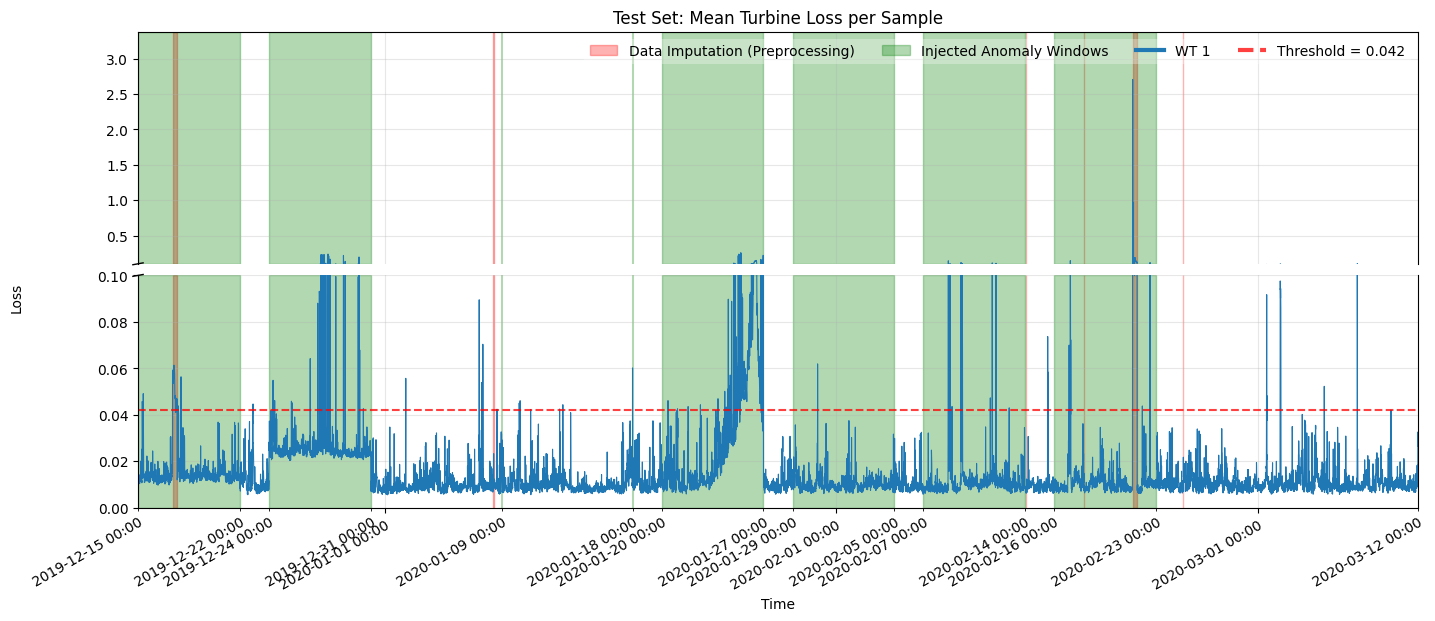

In [26]:
cat_win_path = ic.PATH_PART1_K_AGG_METRICS_DIR / "anom_windows.csv"

cat_windows = pd.read_csv(cat_win_path)

spans_all = list(zip(pd.to_datetime(cat_windows[ce.AnomOverviewKeys.TS_START]),
                     pd.to_datetime(cat_windows[ce.AnomOverviewKeys.TS_END])))

for i in spans_all:
    print(i)

fp_best_k = ic.PATH_PART1_K_AGG_METRICS_DIR / "best_ks_per_wt.csv"

threshold_df = pd.read_csv(fp_best_k)
display(threshold_df.head(10))
theta = threshold_df["threshold"].iloc[0]

pp.print_loss(val_inj_df_eval,
              dpi=300,
              y_limits=((0,0.1),(0.1,0.7)),
              title="Test Set: Mean Turbine Loss per Sample",
              wt_id= [1],
            #   ts_range=("2018-08-01 00:00:00","2018-10-28 00:00:00"),
              ts_range=(ic.START_ANOM, '2020-03-12 00:00:00'),
              anomaly_spans=spans_all,
              line_width=0.8,
              mark_threshold=theta,
              show_mean=False)

In [27]:
# files = glob(os.path.join(ic.PATH_IMPUTED, "*.csv"))
# os.makedirs(ic.PATH_PART1_TEST_SET_DIR, exist_ok=True)

# for f in files:
#     df = pd.read_csv(f)
#     wt_id = df[ic.WT_ID].iat[0]
#     mask = df[ic.TS_COL].between(ic.TRAIN_START , ic.TRAIN_END, inclusive="both")
#     df = df[mask]
#     df.to_csv(os.path.join(ic.PATH_PART1_TEST_SET_DIR, f"wt_id_{wt_id}.csv"), index=False)

In [28]:
# train_loader,val_loader , test_loader = hfn.build_dataloaders(
#                   train_csv_dir=ic.PATH_PC_FILTERING,
#                   val_csv_dir=ic.PATH_IMPUTED,
#                   test_csv_dir=ic.PATH_PC_FILTERING,
#                   cfg=cfg_dummy, # cfg.part1 = true -> only 
#                   filter_fns=[lambda df: ia.inject_anom_type(df, 
#                     start_ts=pd.to_datetime(start1_anom), 
#                     end_ts=pd.to_datetime(end1_anom),
#                     slope=100,
#                     target_col=sig,
#                     wt_id=1,
#                     operator=anomtype.CONST_OFFSET,
#                     ),
#                     lambda df: ia.inject_anom_type(
#                       df, 
#                       start_ts=pd.to_datetime(start2_anom), 
#                       end_ts=pd.to_datetime(end2_anom),
#                       slope=0.5,
#                       target_col=sig,
#                       wt_id=1,
#                       operator=anomtype.MULT_DRIFT,
#                     ),
#                     lambda df: ia.inject_corr_anomaly(
#                       df,
#                       signal1=sig2,
#                       signal2=sig,
#                       window=(start3_anom,end3_anom),
#                       corr_target=0.91,
#                       seed=cfg_dummy.seed,
#                       wt_id=1,
#                       max_iters= 30,
#                       enforce_nonneg=False
#                       )]
#                   )

# origin_test_loader,_ , _ = hfn.build_dataloaders(
#                   train_csv_dir=ic.PATH_PC_FILTERING,
#                   val_csv_dir=ic.PATH_IMPUTED,
#                   test_csv_dir=ic.PATH_PC_FILTERING,
#                   cfg=cfg_dummy
#                   )

In [29]:
# # df_test = hfn.loader_to_df_scaled(origin_test_loader)
# # df_test_anom = hfn.loader_to_df_scaled(test_loader)

# df_test = cast(hfn.MultiCSVDataset, origin_test_loader.dataset).to_df()
# df_test_anom = cast(hfn.MultiCSVDataset, test_loader.dataset).to_df()

# # def_test_anom = ia.inject_anom_type(def_test_anom, 
# #                     start_ts=pd.to_datetime(ic.START_ANOM), 
# #                     end_ts=pd.to_datetime(ic.END_ANOM),
# #                     slope=0.1,
# #                     target_col=sig,
# #                     wt_id=1,
# #                     operator=anomtype.CONST_OFFSET,
# #                     )

# pp.plot_signal_or_compare(df1=df_test,
#                           df2=df_test_anom,
#                           sig=sig, 
#                           wt_id=1,
#                           anomaly_window=(ic.START_ANOM, ic.END_ANOM))

# def slice(df, wt, cols):
#     df_window = df[df[ic.WT_ID].astype(int) == int(wt)].copy()
#     df_window[ic.TS_COL] = pd.to_datetime(df_window[ic.TS_COL], errors="raise")
#     df_window = df_window.sort_values(ic.TS_COL)
#     mask = (df_window[ic.TS_COL] >= start3_anom) & (df_window[ic.TS_COL] <= end3_anom)

#     df_ = df_window.loc[mask, [ic.TS_COL, *cols]]
#     return df_

# wt=1
# df_before = slice(df_test, wt, [sig,sig2]).rename(columns={sig: f"s2_before_{sig}", sig2:f"s1_{sig2}"})
# df_after = slice(df_test_anom, wt, [sig, sig2]).rename(columns={sig: f"s2_after_{sig}"})

# S = pd.merge(
#     df_before[[ic.TS_COL, f"s2_before_{sig}", f"s1_{sig2}"]], 
#     df_after[[ic.TS_COL, f"s2_after_{sig}"]], 
#     on=ic.TS_COL, 
#     how="inner")

# s1_scaled = S[f"s1_{sig2}"].to_numpy(dtype=float)
# s2_scaled_old = S[f"s2_before_{sig}"].to_numpy(dtype=float)
# s2_scaled_new = S[f"s2_after_{sig}"].to_numpy(dtype=float)

# stats = ea.quick_corr_stats(s1_scaled, s2_scaled_old, s2_scaled_new)

# print("corr stats:", stats)


# pp.plot_signal_or_compare(df1=df_test_anom,
#                           df2=None,
#                           sig=sig, 
#                           wt_id=1,
#                           anomaly_window=(ic.START_ANOM, ic.END_ANOM))



In [30]:
# threshold_table = ce.Eval_Anom.build_threshold_table_part2(
#     mu_sigma_df=sigma_df,
#     best_k_per_wt=best_k_per_wt_df,
#     save_dir = out_dir,
#     csv_name = ""
# )

# display(threshold_table.head())

# threshold_table.to_csv(fp_thresh, index=False)